# 04 — Churn Dashboard Analytics

Este notebook prepara e valida as análises que serão apresentadas no dashboard do FinPulse AI.

## Objetivos

- analisar a carteira completa de clientes;
- identificar clientes com maior risco de churn;
- definir os principais KPIs do dashboard;
- criar segmentos de risco e prioridade;
- validar gráficos e tabelas antes da implementação no Streamlit.

## 1. Carregamento dos dados

Nesta etapa, carregamos o mart de scoring produzido pelo dbt. Essa tabela contém a carteira de clientes e as previsões geradas pelo modelo champion registrado no MLflow.

In [44]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, inspect

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid")

In [46]:
import os

print("POSTGRES_PASSWORD configurada:", "POSTGRES_PASSWORD" in os.environ)

POSTGRES_PASSWORD configurada: False


In [47]:
from sqlalchemy import URL

database_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("POSTGRES_USER", "finpulse_user"),
    password=os.getenv("POSTGRES_PASSWORD", "finpulse_password"),
    host=os.getenv("POSTGRES_HOST", "postgres"),
    port=int(os.getenv("POSTGRES_PORT", "5432")),
    database=os.getenv("POSTGRES_DB", "finpulse"),
)

engine = create_engine(database_url, pool_pre_ping=True)

with engine.connect() as connection:
    connection.exec_driver_sql("SELECT 1")

print("✅ Conexão com o PostgreSQL realizada com sucesso!")

✅ Conexão com o PostgreSQL realizada com sucesso!


### 1.1 Leitura do mart de churn

Carregamos a carteira completa com as previsões produzidas pelo modelo champion. Antes de definir os KPIs, validamos o volume, as colunas e a estrutura dos dados disponíveis.

In [12]:
query = """
SELECT *
FROM marts.mart_customer_churn_model
"""

df_churn = pd.read_sql(query, engine)

print(f"✅ Clientes carregados: {len(df_churn):,}")
print(f"✅ Colunas disponíveis: {df_churn.shape[1]}")

✅ Clientes carregados: 10,127
✅ Colunas disponíveis: 21


In [13]:
df_churn.head()

,customer_id,churn_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_last_12m,contacts_count_last_12m,credit_limit,total_revolving_balance,average_open_to_buy,amount_change_q4_q1,total_transaction_amount,total_transaction_count,transaction_count_change_q4_q1,average_utilization_ratio
0,768805383,0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,"12,691.0000",777.0000,"11,914.0000",1.3350,"1,144.0000",42,1.6250,0.0610
1,818770008,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,"8,256.0000",864.0000,"7,392.0000",1.5410,"1,291.0000",33,3.7140,0.1050
2,713982108,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,"3,418.0000",0.0000,"3,418.0000",2.5940,"1,887.0000",20,2.3330,0.0000
3,769911858,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,"3,313.0000","2,517.0000",796.0000,1.4050,"1,171.0000",20,2.3330,0.7600
4,709106358,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,"4,716.0000",0.0000,"4,716.0000",2.1750,816.0000,28,2.5000,0.0000


In [14]:
query = """
WITH latest_predictions AS (
    SELECT
        customer_id,
        churn_probability,
        risk_band,
        churn_prediction,
        model_name,
        model_version,
        model_alias,
        scored_at,
        scoring_run_id,
        snapshot_uri,
        ROW_NUMBER() OVER (
            PARTITION BY customer_id
            ORDER BY scored_at DESC
        ) AS row_number
    FROM marts.mart_customer_churn_predictions
)

SELECT
    customer.*,
    prediction.churn_probability,
    prediction.risk_band,
    prediction.churn_prediction,
    prediction.model_name,
    prediction.model_version,
    prediction.model_alias,
    prediction.scored_at,
    prediction.scoring_run_id,
    prediction.snapshot_uri
FROM marts.mart_customer_churn_model AS customer
LEFT JOIN latest_predictions AS prediction
    ON customer.customer_id = prediction.customer_id
   AND prediction.row_number = 1
"""

df_churn = pd.read_sql(query, engine)

print(f"✅ Clientes carregados: {len(df_churn):,}")
print(f"✅ Colunas disponíveis: {df_churn.shape[1]}")
print(
    f"✅ Clientes com previsão: "
    f"{df_churn['churn_probability'].notna().sum():,}"
)

✅ Clientes carregados: 10,127
✅ Colunas disponíveis: 30
✅ Clientes com previsão: 10,127


In [15]:
df_churn[
    [
        "customer_id",
        "churn_flag",
        "churn_probability",
        "risk_band",
        "churn_prediction",
        "model_version",
        "model_alias",
    ]
].head(10)

,customer_id,churn_flag,churn_probability,risk_band,churn_prediction,model_version,model_alias
0,768805383,0,0.0001,Low,0,3,champion
1,818770008,0,0.0001,Low,0,3,champion
2,713982108,0,0.0007,Low,0,3,champion
3,769911858,0,0.0008,Low,0,3,champion
4,709106358,0,0.0457,Low,0,3,champion
5,713061558,0,0.0013,Low,0,3,champion
6,810347208,0,0.0001,Low,0,3,champion
7,818906208,0,0.0025,Low,0,3,champion
8,710930508,0,0.0002,Low,0,3,champion
9,719661558,0,0.0002,Low,0,3,champion


### 1.2 Validação da integração entre carteira e previsões

Validamos se todos os clientes possuem uma única previsão, se existem valores ausentes e se o dashboard está utilizando o modelo champion esperado.

In [17]:
validation = {
    "total_rows": len(df_churn),
    "unique_customers": df_churn["customer_id"].nunique(),
    "duplicated_customers": df_churn["customer_id"].duplicated().sum(),
    "missing_predictions": df_churn["churn_probability"].isna().sum(),
    "invalid_probabilities": (
        ~df_churn["churn_probability"].between(0, 1)
    ).sum(),
}

for check, value in validation.items():
    print(f"{check}: {value:,}")

print("\nFaixas de risco:")
display(
    df_churn["risk_band"]
    .value_counts(dropna=False)
    .rename_axis("risk_band")
    .to_frame("customers")
)

print("\nModelo utilizado:")
display(
    df_churn[
        ["model_name", "model_version", "model_alias", "scoring_run_id", "scored_at"]
    ].drop_duplicates()
)

total_rows: 10,127
unique_customers: 10,127
duplicated_customers: 0
missing_predictions: 0
invalid_probabilities: 0

Faixas de risco:


,customers
risk_band,
Low,8354
High,1599
Medium,174



Modelo utilizado:


,model_name,model_version,model_alias,scoring_run_id,scored_at
0,finpulse-churn-catboost,3,champion,70766c70fc5f45d6ba2c9b4022b183e9,2026-07-18 12:38:19.920397+00:00


## 2. KPIs da Visão Principal

Calculamos os indicadores executivos que resumem o tamanho da carteira, o churn observado e o risco identificado pelo modelo champion.

In [18]:
total_customers = df_churn["customer_id"].nunique()

observed_churn_customers = int(df_churn["churn_flag"].sum())
observed_churn_rate = df_churn["churn_flag"].mean()

high_risk_customers = int(
    df_churn["risk_band"].eq("High").sum()
)
high_risk_rate = df_churn["risk_band"].eq("High").mean()

predicted_churn_customers = int(
    df_churn["churn_prediction"].sum()
)
average_churn_probability = df_churn["churn_probability"].mean()

kpis = pd.Series(
    {
        "Total de clientes": total_customers,
        "Churn observado": observed_churn_customers,
        "Taxa de churn observada": observed_churn_rate,
        "Clientes em alto risco": high_risk_customers,
        "Percentual em alto risco": high_risk_rate,
        "Churn previsto pelo modelo": predicted_churn_customers,
        "Probabilidade média de churn": average_churn_probability,
    }
)

display(kpis.to_frame("value"))

,value
Total de clientes,"10,127.0000"
Churn observado,"1,627.0000"
Taxa de churn observada,0.1607
Clientes em alto risco,"1,599.0000"
Percentual em alto risco,0.1579
Churn previsto pelo modelo,"1,599.0000"
Probabilidade média de churn,0.1596


In [19]:
print(f"👥 Total de clientes: {total_customers:,}")
print(
    f"📉 Churn observado: {observed_churn_customers:,} "
    f"({observed_churn_rate:.2%})"
)
print(
    f"🚨 Clientes em alto risco: {high_risk_customers:,} "
    f"({high_risk_rate:.2%})"
)
print(f"🤖 Churn previsto: {predicted_churn_customers:,}")
print(
    f"📊 Probabilidade média de churn: "
    f"{average_churn_probability:.2%}"
)

👥 Total de clientes: 10,127
📉 Churn observado: 1,627 (16.07%)
🚨 Clientes em alto risco: 1,599 (15.79%)
🤖 Churn previsto: 1,599
📊 Probabilidade média de churn: 15.96%


### 2.1 Comparação entre churn observado e previsto

Comparamos o resultado conhecido com a previsão do modelo champion. Também separamos os clientes ativos sinalizados pelo modelo, que representam oportunidades de atuação em uma simulação operacional.

In [20]:
comparison = pd.crosstab(
    df_churn["churn_flag"],
    df_churn["churn_prediction"],
    rownames=["Churn observado"],
    colnames=["Churn previsto"],
    margins=True,
)

display(comparison)

Churn previsto,0,1,All
Churn observado,,,
0,8467,33,8500
1,61,1566,1627
All,8528,1599,10127


In [21]:
true_negative = int(
    ((df_churn["churn_flag"] == 0) &
     (df_churn["churn_prediction"] == 0)).sum()
)

false_positive = int(
    ((df_churn["churn_flag"] == 0) &
     (df_churn["churn_prediction"] == 1)).sum()
)

false_negative = int(
    ((df_churn["churn_flag"] == 1) &
     (df_churn["churn_prediction"] == 0)).sum()
)

true_positive = int(
    ((df_churn["churn_flag"] == 1) &
     (df_churn["churn_prediction"] == 1)).sum()
)

print(f"✅ Permanência identificada corretamente: {true_negative:,}")
print(f"⚠️ Clientes ativos sinalizados como churn: {false_positive:,}")
print(f"❌ Churns não identificados pelo modelo: {false_negative:,}")
print(f"✅ Churns identificados corretamente: {true_positive:,}")

✅ Permanência identificada corretamente: 8,467
⚠️ Clientes ativos sinalizados como churn: 33
❌ Churns não identificados pelo modelo: 61
✅ Churns identificados corretamente: 1,566


In [22]:
df_active = df_churn.loc[df_churn["churn_flag"] == 0].copy()

active_high_risk = df_active.loc[
    df_active["risk_band"] == "High"
].copy()

print(f"Clientes ainda ativos: {len(df_active):,}")
print(f"Ativos classificados como alto risco: {len(active_high_risk):,}")
print(
    "Percentual da carteira ativa em alto risco: "
    f"{len(active_high_risk) / len(df_active):.2%}"
)

Clientes ainda ativos: 8,500
Ativos classificados como alto risco: 33
Percentual da carteira ativa em alto risco: 0.39%


### 2.2 Separação entre indicadores de negócio e monitoramento

A matriz anterior é utilizada como análise retrospectiva da carteira completa. Ela não substitui a avaliação oficial realizada no conjunto de teste e registrada no MLflow.

Para o dashboard, separamos:

- indicadores executivos da carteira;
- indicadores preditivos do scoring;
- indicadores oficiais de desempenho do modelo;
- simulação operacional dos clientes historicamente ativos sinalizados.

In [23]:
dashboard_metric_map = pd.DataFrame(
    [
        {
            "metric": "Total de clientes",
            "value": total_customers,
            "dashboard_page": "Visão Principal",
            "metric_type": "Carteira",
        },
        {
            "metric": "Churn observado",
            "value": observed_churn_customers,
            "dashboard_page": "Visão Principal",
            "metric_type": "Histórico",
        },
        {
            "metric": "Taxa de churn observada",
            "value": observed_churn_rate,
            "dashboard_page": "Visão Principal",
            "metric_type": "Histórico",
        },
        {
            "metric": "Clientes em alto risco",
            "value": high_risk_customers,
            "dashboard_page": "Visão Principal",
            "metric_type": "Predição",
        },
        {
            "metric": "Probabilidade média de churn",
            "value": average_churn_probability,
            "dashboard_page": "Visão Principal",
            "metric_type": "Predição",
        },
        {
            "metric": "Ativos sinalizados como alto risco",
            "value": len(active_high_risk),
            "dashboard_page": "Priorização",
            "metric_type": "Simulação retrospectiva",
        },
        {
            "metric": "Verdadeiros positivos",
            "value": true_positive,
            "dashboard_page": "Monitoramento do Modelo",
            "metric_type": "Diagnóstico",
        },
        {
            "metric": "Falsos positivos",
            "value": false_positive,
            "dashboard_page": "Monitoramento do Modelo",
            "metric_type": "Diagnóstico",
        },
        {
            "metric": "Falsos negativos",
            "value": false_negative,
            "dashboard_page": "Monitoramento do Modelo",
            "metric_type": "Diagnóstico",
        },
        {
            "metric": "Verdadeiros negativos",
            "value": true_negative,
            "dashboard_page": "Monitoramento do Modelo",
            "metric_type": "Diagnóstico",
        },
    ]
)

display(dashboard_metric_map)

,metric,value,dashboard_page,metric_type
0,Total de clientes,"10,127.0000",Visão Principal,Carteira
1,Churn observado,"1,627.0000",Visão Principal,Histórico
2,Taxa de churn observada,0.1607,Visão Principal,Histórico
3,Clientes em alto risco,"1,599.0000",Visão Principal,Predição
4,Probabilidade média de churn,0.1596,Visão Principal,Predição
5,Ativos sinalizados como alto risco,33.0000,Priorização,Simulação retrospectiva
6,Verdadeiros positivos,"1,566.0000",Monitoramento do Modelo,Diagnóstico
7,Falsos positivos,33.0000,Monitoramento do Modelo,Diagnóstico
8,Falsos negativos,61.0000,Monitoramento do Modelo,Diagnóstico
9,Verdadeiros negativos,"8,467.0000",Monitoramento do Modelo,Diagnóstico


## 3. Distribuição preditiva de risco

Analisamos como a carteira está distribuída entre as faixas de risco definidas pelo modelo champion. Esse indicador permite visualizar rapidamente a concentração de clientes com maior probabilidade de churn.

In [24]:
risk_order = ["Low", "Medium", "High"]

risk_distribution = (
    df_churn["risk_band"]
    .value_counts()
    .reindex(risk_order, fill_value=0)
    .rename_axis("risk_band")
    .reset_index(name="customers")
)

risk_distribution["percentage"] = (
    risk_distribution["customers"] / total_customers
)

display(risk_distribution)

,risk_band,customers,percentage
0,Low,8354,0.8249
1,Medium,174,0.0172
2,High,1599,0.1579


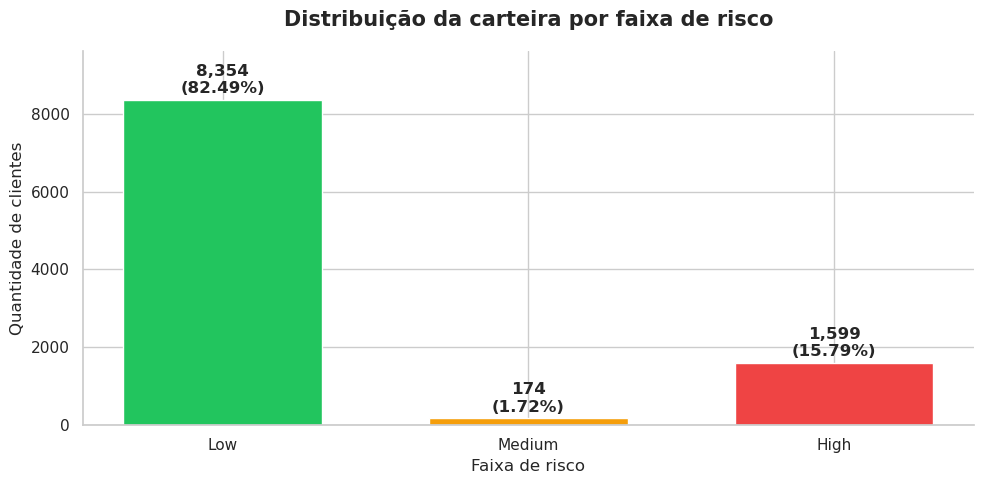

In [25]:
risk_colors = {
    "Low": "#22C55E",
    "Medium": "#F59E0B",
    "High": "#EF4444",
}

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    risk_distribution["risk_band"],
    risk_distribution["customers"],
    color=[
        risk_colors[risk_band]
        for risk_band in risk_distribution["risk_band"]
    ],
    width=0.65,
)

for bar, customers, percentage in zip(
    bars,
    risk_distribution["customers"],
    risk_distribution["percentage"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{customers:,.0f}\n({percentage:.2%})",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax.set_title(
    "Distribuição da carteira por faixa de risco",
    fontsize=15,
    fontweight="bold",
    pad=18,
)
ax.set_xlabel("Faixa de risco")
ax.set_ylabel("Quantidade de clientes")
ax.set_ylim(0, risk_distribution["customers"].max() * 1.15)

sns.despine()
plt.tight_layout()
plt.show()

### 3.1 Impacto financeiro por faixa de risco

Além da quantidade de clientes, analisamos quanto do limite de crédito e do volume transacionado está associado a cada faixa de risco. Essa visão ajuda a dimensionar o impacto financeiro potencial do churn.

In [29]:
risk_financial_impact = (
    df_churn
    .groupby("risk_band", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        total_credit_limit=("credit_limit", "sum"),
        average_credit_limit=("credit_limit", "mean"),
        total_transaction_amount=("total_transaction_amount", "sum"),
        average_transaction_amount=("total_transaction_amount", "mean"),
        average_churn_probability=("churn_probability", "mean"),
    )
    .reindex(risk_order)
    .reset_index()
)

risk_financial_impact["credit_limit_share"] = (
    risk_financial_impact["total_credit_limit"]
    / risk_financial_impact["total_credit_limit"].sum()
)

risk_financial_impact["transaction_amount_share"] = (
    risk_financial_impact["total_transaction_amount"]
    / risk_financial_impact["total_transaction_amount"].sum()
)

display(risk_financial_impact)

,risk_band,customers,total_credit_limit,average_credit_limit,total_transaction_amount,average_transaction_amount,average_churn_probability,credit_limit_share,transaction_amount_share
0,Low,8354,"73,024,475.4000","8,741.2587","39,187,404.0000","4,690.8552",0.0108,0.8354,0.8786
1,Medium,174,"1,500,824.0000","8,625.4253","457,163.0000","2,627.3736",0.3146,0.0172,0.0103
2,High,1599,"12,890,495.7000","8,061.5983","4,955,615.0000","3,099.1964",0.9205,0.1475,0.1111


In [30]:
for row in risk_financial_impact.itertuples():
    print(
        f"{row.risk_band}: {row.customers:,} clientes | "
        f"Limite: US$ {row.total_credit_limit:,.2f} | "
        f"Volume transacionado: US$ {row.total_transaction_amount:,.2f} | "
        f"Probabilidade média: {row.average_churn_probability:.2%}"
    )

Low: 8,354 clientes | Limite: US$ 73,024,475.40 | Volume transacionado: US$ 39,187,404.00 | Probabilidade média: 1.08%
Medium: 174 clientes | Limite: US$ 1,500,824.00 | Volume transacionado: US$ 457,163.00 | Probabilidade média: 31.46%
High: 1,599 clientes | Limite: US$ 12,890,495.70 | Volume transacionado: US$ 4,955,615.00 | Probabilidade média: 92.05%


### 3.2 Exposição financeira por faixa de risco

Comparamos o limite de crédito concedido e o volume histórico transacionado em cada faixa de risco. Os valores representam exposição associada ao risco, não uma estimativa direta de perda financeira.

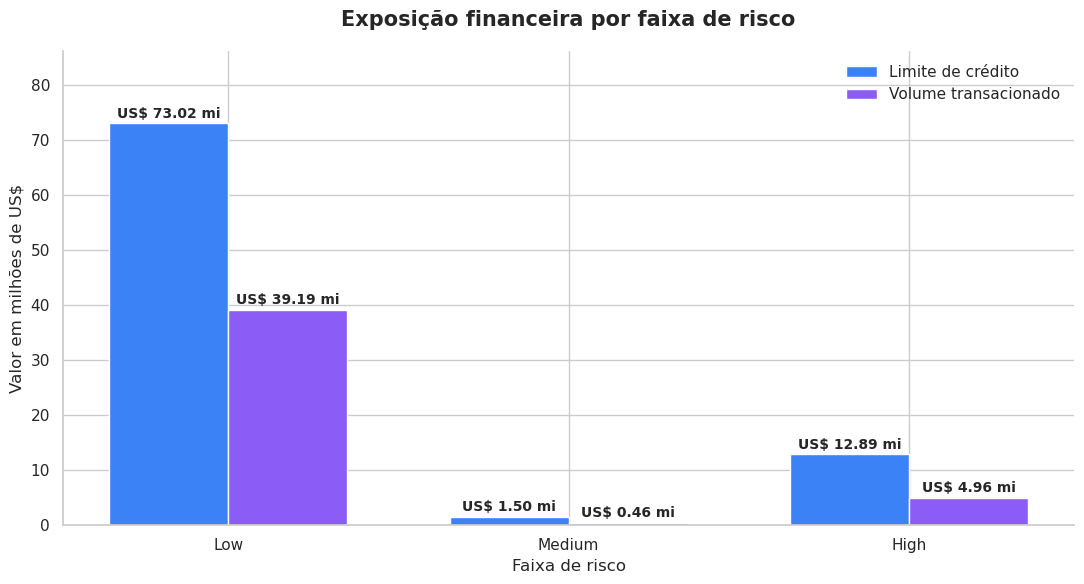

In [31]:
financial_chart = risk_financial_impact.copy()

financial_chart["credit_limit_millions"] = (
    financial_chart["total_credit_limit"] / 1_000_000
)

financial_chart["transaction_amount_millions"] = (
    financial_chart["total_transaction_amount"] / 1_000_000
)

x = range(len(financial_chart))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

credit_bars = ax.bar(
    [position - bar_width / 2 for position in x],
    financial_chart["credit_limit_millions"],
    width=bar_width,
    label="Limite de crédito",
    color="#3B82F6",
)

transaction_bars = ax.bar(
    [position + bar_width / 2 for position in x],
    financial_chart["transaction_amount_millions"],
    width=bar_width,
    label="Volume transacionado",
    color="#8B5CF6",
)

for bars in (credit_bars, transaction_bars):
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"US$ {bar.get_height():.2f} mi",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

ax.set_title(
    "Exposição financeira por faixa de risco",
    fontsize=15,
    fontweight="bold",
    pad=18,
)
ax.set_xlabel("Faixa de risco")
ax.set_ylabel("Valor em milhões de US$")
ax.set_xticks(list(x))
ax.set_xticklabels(financial_chart["risk_band"])
ax.legend(frameon=False)
ax.set_ylim(
    0,
    financial_chart[
        ["credit_limit_millions", "transaction_amount_millions"]
    ].to_numpy().max() * 1.18,
)

sns.despine()
plt.tight_layout()
plt.show()

In [32]:
high_risk_financial = risk_financial_impact.loc[
    risk_financial_impact["risk_band"] == "High"
].iloc[0]

print(
    f"🚨 {high_risk_financial['customers']:,.0f} clientes estão em alto risco "
    f"({high_risk_rate:.2%} da carteira)."
)

print(
    f"💳 Esses clientes concentram "
    f"US$ {high_risk_financial['total_credit_limit'] / 1_000_000:,.2f} milhões "
    f"em limite de crédito "
    f"({high_risk_financial['credit_limit_share']:.2%} do total)."
)

print(
    f"💰 O volume histórico transacionado por esse grupo é de "
    f"US$ {high_risk_financial['total_transaction_amount'] / 1_000_000:,.2f} milhões "
    f"({high_risk_financial['transaction_amount_share']:.2%} do total)."
)

🚨 1,599 clientes estão em alto risco (15.79% da carteira).
💳 Esses clientes concentram US$ 12.89 milhões em limite de crédito (14.75% do total).
💰 O volume histórico transacionado por esse grupo é de US$ 4.96 milhões (11.11% do total).


### 3.3 Churn observado por faixa de risco

Comparamos as faixas produzidas pelo modelo com o churn historicamente observado. Essa análise retrospectiva permite verificar se as faixas de maior risco concentram, de fato, uma proporção maior de clientes que deixaram o banco.

In [33]:
risk_observed_churn = (
    df_churn
    .groupby("risk_band", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        observed_churn_customers=("churn_flag", "sum"),
        observed_churn_rate=("churn_flag", "mean"),
        average_churn_probability=("churn_probability", "mean"),
    )
    .reindex(risk_order)
    .reset_index()
)

risk_observed_churn["active_customers"] = (
    risk_observed_churn["customers"]
    - risk_observed_churn["observed_churn_customers"]
)

display(risk_observed_churn)

,risk_band,customers,observed_churn_customers,observed_churn_rate,average_churn_probability,active_customers
0,Low,8354,22,0.0026,0.0108,8332
1,Medium,174,39,0.2241,0.3146,135
2,High,1599,1566,0.9794,0.9205,33


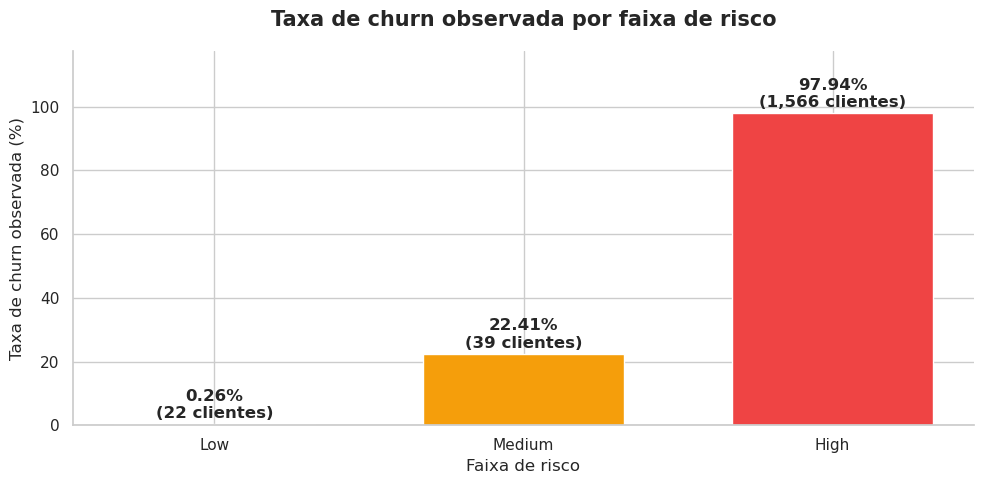

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    risk_observed_churn["risk_band"],
    risk_observed_churn["observed_churn_rate"] * 100,
    color=[
        risk_colors[risk_band]
        for risk_band in risk_observed_churn["risk_band"]
    ],
    width=0.65,
)

for bar, rate, churn_customers in zip(
    bars,
    risk_observed_churn["observed_churn_rate"],
    risk_observed_churn["observed_churn_customers"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.2%}\n({churn_customers:,.0f} clientes)",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax.set_title(
    "Taxa de churn observada por faixa de risco",
    fontsize=15,
    fontweight="bold",
    pad=18,
)
ax.set_xlabel("Faixa de risco")
ax.set_ylabel("Taxa de churn observada (%)")
ax.set_ylim(
    0,
    max(risk_observed_churn["observed_churn_rate"] * 100) * 1.20,
)

sns.despine()
plt.tight_layout()
plt.show()

### 3.4 Efetividade da segmentação de risco

A faixa de alto risco concentrou 96,25% dos churns observados na carteira. Sua taxa de churn foi de 97,94%, aproximadamente 6,1 vezes superior à taxa geral de 16,07%.

A análise demonstra que as faixas produzidas pelo modelo distinguem claramente clientes de baixo, médio e alto risco. Os resultados são retrospectivos e não substituem as métricas oficiais do conjunto de teste registradas no MLflow.

In [35]:
total_observed_churn = int(df_churn["churn_flag"].sum())

high_risk_observed_churn = int(
    risk_observed_churn.loc[
        risk_observed_churn["risk_band"] == "High",
        "observed_churn_customers",
    ].iloc[0]
)

high_risk_observed_rate = float(
    risk_observed_churn.loc[
        risk_observed_churn["risk_band"] == "High",
        "observed_churn_rate",
    ].iloc[0]
)

churn_concentration_high = (
    high_risk_observed_churn / total_observed_churn
)

high_risk_lift = (
    high_risk_observed_rate / observed_churn_rate
)

print(
    f"Churns concentrados no alto risco: "
    f"{high_risk_observed_churn:,} de {total_observed_churn:,} "
    f"({churn_concentration_high:.2%})"
)

print(
    f"Taxa de churn no alto risco: "
    f"{high_risk_observed_rate:.2%}"
)

print(
    f"Lift da faixa de alto risco: "
    f"{high_risk_lift:.2f}x"
)

Churns concentrados no alto risco: 1,566 de 1,627 (96.25%)
Taxa de churn no alto risco: 97.94%
Lift da faixa de alto risco: 6.10x


## 4. Consolidação da Visão Geral

Consolidamos os indicadores validados no notebook no mesmo formato lógico dos futuros marts do dashboard. Esses resultados serão posteriormente implementados no dbt e consumidos diretamente pelo Streamlit.

In [36]:
dashboard_overview = pd.DataFrame(
    [
        {
            "total_customers": total_customers,
            "observed_churn_customers": observed_churn_customers,
            "observed_churn_rate": observed_churn_rate,
            "high_risk_customers": high_risk_customers,
            "high_risk_rate": high_risk_rate,
            "average_churn_probability": average_churn_probability,
            "high_risk_credit_limit": high_risk_financial[
                "total_credit_limit"
            ],
            "high_risk_transaction_amount": high_risk_financial[
                "total_transaction_amount"
            ],
            "high_risk_credit_limit_share": high_risk_financial[
                "credit_limit_share"
            ],
            "high_risk_transaction_share": high_risk_financial[
                "transaction_amount_share"
            ],
            "high_risk_observed_churn": high_risk_observed_churn,
            "high_risk_observed_churn_rate": high_risk_observed_rate,
            "churn_concentration_high": churn_concentration_high,
            "high_risk_lift": high_risk_lift,
            "model_version": df_churn["model_version"].iloc[0],
            "model_alias": df_churn["model_alias"].iloc[0],
            "scoring_run_id": df_churn["scoring_run_id"].iloc[0],
            "scored_at": df_churn["scored_at"].max(),
        }
    ]
)

display(dashboard_overview.T.rename(columns={0: "value"}))

,value
total_customers,10127
observed_churn_customers,1627
observed_churn_rate,0.1607
high_risk_customers,1599
high_risk_rate,0.1579
average_churn_probability,0.1596
high_risk_credit_limit,"12,890,495.7000"
high_risk_transaction_amount,"4,955,615.0000"
high_risk_credit_limit_share,0.1475
high_risk_transaction_share,0.1111


In [37]:
dashboard_risk_distribution = (
    risk_financial_impact[
        [
            "risk_band",
            "customers",
            "total_credit_limit",
            "average_credit_limit",
            "total_transaction_amount",
            "average_transaction_amount",
            "average_churn_probability",
            "credit_limit_share",
            "transaction_amount_share",
        ]
    ]
    .merge(
        risk_observed_churn[
            [
                "risk_band",
                "observed_churn_customers",
                "active_customers",
                "observed_churn_rate",
            ]
        ],
        on="risk_band",
        how="left",
        validate="one_to_one",
    )
)

dashboard_risk_distribution["customer_share"] = (
    dashboard_risk_distribution["customers"] / total_customers
)

dashboard_risk_distribution["scoring_run_id"] = (
    df_churn["scoring_run_id"].iloc[0]
)

display(dashboard_risk_distribution)

,risk_band,customers,total_credit_limit,average_credit_limit,total_transaction_amount,average_transaction_amount,average_churn_probability,credit_limit_share,transaction_amount_share,observed_churn_customers,active_customers,observed_churn_rate,customer_share,scoring_run_id
0,Low,8354,"73,024,475.4000","8,741.2587","39,187,404.0000","4,690.8552",0.0108,0.8354,0.8786,22,8332,0.0026,0.8249,70766c70fc5f45d6ba2c9b4022b183e9
1,Medium,174,"1,500,824.0000","8,625.4253","457,163.0000","2,627.3736",0.3146,0.0172,0.0103,39,135,0.2241,0.0172,70766c70fc5f45d6ba2c9b4022b183e9
2,High,1599,"12,890,495.7000","8,061.5983","4,955,615.0000","3,099.1964",0.9205,0.1475,0.1111,1566,33,0.9794,0.1579,70766c70fc5f45d6ba2c9b4022b183e9


In [39]:
from sqlalchemy import text
query_tables = """
SELECT
    table_schema,
    table_name
FROM information_schema.tables
WHERE table_name ILIKE '%churn%'
ORDER BY table_schema, table_name
"""

pd.read_sql(text(query_tables), engine)

,table_schema,table_name
0,marts,mart_customer_churn_model
1,marts,mart_customer_churn_predictions
2,raw,bank_churners
3,staging,stg_bank_churners


In [40]:
query_overview = """
SELECT *
FROM marts.mart_churn_dashboard_overview
"""

dbt_dashboard_overview = pd.read_sql(
    text(query_overview),
    engine,
)

display(dbt_dashboard_overview.T.rename(columns={0: "value"}))

,value
total_customers,10127
observed_churn_customers,1627
observed_churn_rate,0.1607
high_risk_customers,1599
high_risk_rate,0.1579
average_churn_probability,0.1596
high_risk_credit_limit,"12,890,495.7000"
high_risk_transaction_amount,"4,955,615.0000"
high_risk_credit_limit_share,0.1475
high_risk_transaction_share,0.1111


In [41]:
query_risk_distribution = """
SELECT *
FROM marts.mart_churn_risk_distribution
ORDER BY risk_order
"""

dbt_risk_distribution = pd.read_sql(
    text(query_risk_distribution),
    engine,
)

display(dbt_risk_distribution)

,risk_band,risk_order,customers,customer_share,total_credit_limit,average_credit_limit,total_transaction_amount,average_transaction_amount,average_churn_probability,credit_limit_share,transaction_amount_share,observed_churn_customers,active_customers,observed_churn_rate,model_version,model_alias,scoring_run_id,scored_at
0,Low,1,8354,0.8249,"73,024,475.4000","8,741.2587","39,187,404.0000","4,690.8552",0.0108,0.8354,0.8786,22,8332,0.0026,3,champion,70766c70fc5f45d6ba2c9b4022b183e9,2026-07-18 12:38:19.920397+00:00
1,Medium,2,174,0.0172,"1,500,824.0000","8,625.4253","457,163.0000","2,627.3736",0.3146,0.0172,0.0103,39,135,0.2241,3,champion,70766c70fc5f45d6ba2c9b4022b183e9,2026-07-18 12:38:19.920397+00:00
2,High,3,1599,0.1579,"12,890,495.7000","8,061.5983","4,955,615.0000","3,099.1964",0.9205,0.1475,0.1111,1566,33,0.9794,3,champion,70766c70fc5f45d6ba2c9b4022b183e9,2026-07-18 12:38:19.920397+00:00
